# Profile processing Step 1: Pre-processing CTD, identification of data groups, and image tags

works with the raw CTD time series, Castaway processed CTD profiles, and all of the images in the folder to sync the time and create files that will be used in the next step to associate a time, depth, salinity, and temperature with every particle identified by the image processing output. It is in this notebook that you will also select specific intervals within the cast to process (if desired) and identify the total depth (which is needed later on in processing the profile data). Three files are required to complete this step of the processing. They are:

1) raw CTD time series
2) Castaway processed CTD profiles
3) The images to process or the images that were processed 

This notebook can be run before or after the image processing. 

The user input needed in the notebook includes:
- specifying the cast to process through the file ```0_CastPath.csv``` (this file needs to be in the same directory as the step 1 notebook)
- any time corrections to match the images (computer clock) and CTD (CTD clock)
- the image file type (e.g., jpg, bmp, etc.) and the file type of the CTD data (should be .csv)

During the execution of the notebook, you will need to identify whether or not there are breakpoints you want to associate with the cast to group the data and how you want to define the depth. Completing these should be self-explanatory as you work through the file.

Files generated through the execution of this notebook include:

- CTD-profile.csv (a renamed copy for easy read in later on)
- CTD-timeseries.csv (a renamed copy for easy read in later on)
- Data-Breakpionts.csv (a list unique set of data groupings for the cast)
- Depth.csv (depth to be used in later profiling)
- ImageTime.csv (list of image day/times)

**version updates**
* v01 manual break-point identification
* v02 optional auto break-point identification

## Python loads and functions

In [1]:
%config InlineBackend.figure_format='retina' # hig-res plots for a Retina display 
import numpy as np
import pandas as pd
import os
import glob
from datetime import datetime, timedelta
import shutil

from breakpoint_detection import detect_constant_depth_periods

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
###define equation for converting conductivity to specific conductance
#C - conductivity in microsiemens/cm
#T - temperature in celcius

def SpC(C,T):
    return C/(1+0.02*(T-25))
    
    
#returns the clear-water density in kg/m^3 as a function of temperature [in deg C] and salinity [ppt]
def rho_cw(T,S): 
    rho_fresh=1000*(1-(T +288.9414)/(508929.2*(T+68.12963))*(T-3.9863)**2)
    Acoef = 0.824493 - 0.0040899*T + 0.000076438*T**2 -0.00000082467*T**3 + 0.0000000053675*T**4
    Bcoef = -0.005724 + 0.00010227*T - 0.0000016546*T**2
    return rho_fresh + Acoef*S + Bcoef*S**(3/2) + 0.00048314*S**2 

## Find files and enter time corrections

In [3]:
""" --- User input ----------------------------- """
# file types and paths
filetype = '*.csv'
imagetype = '*jpg'

# time corrections to be added onto CTD to match Camera stamp (use negative number to substract). Can be for CTD in UTC or local. 
hrC = -3 #0  # hour correction (Xingu)
minC = -57 #0 # min correction (Xingu)
scC = -35   # second correction (Xingu)
# scC = 4    # second correction (Barateria Bay correction)
# scC = 0   # second correction (Siene correction)
tc_ctd_time_used = 1 # 1 for UTC, 2 for local
"""  ------------------------------------------- """

# castpath = '/Users/strom-adm/Documents/Floc-Processing/Code/1_Profile_Processing/0_CastPath.csv'
castpath = '0_CastPath.csv'
Path = pd.read_csv(castpath).profile_path[0]+'/'

CodePath = os.getcwd()
os.chdir(Path)

# find the data files  

files = sorted(glob.glob(filetype))

for i in range(0,len(files)):
    print('file: ',files[i],'(index: ',i,')')

file:  CC1841005_20250929_165726_processed.csv (index:  0 )
file:  CC1841005_20250929_165726_raw.csv (index:  1 )
file:  filemod_list.csv (index:  2 )


## Pick files for CTD processing

In [4]:
""" --- User input ----------------------------- """
m = 0 # pick the processed profile data by choosing the file index
n = 1 # pick the raw CTD time series by choosing the file index

## Process CTD

,Time,Depth [m],P [Decibars],T [Celsius],SpC [MicroSiemens/cm],Time (Seconds),Pressure (Decibar),Temperature (Celsius),Conductivity (MicroSiemens per Centimeter),% Device,CC1841005
0,09292025125951,0.000000,0.000000,0.000000,0.000000,0.2,0.000000,35.203220,0.000000,% File name,CC1841005_20250929_165726
1,09292025125951,0.000000,0.000000,0.000000,0.000000,0.4,-0.011658,35.172295,0.000000,% Cast time (UTC),2025-09-29 16:57:26
2,09292025125951,-0.009285,-0.009109,35.157571,0.000000,0.6,-0.007409,35.163307,0.000000,% Cast time (local),2025-09-29 12:57:26
3,09292025125951,-0.009929,-0.009740,35.133620,0.000000,0.8,-0.007939,35.133995,0.000000,% Sample type,Cast
4,09292025125952,-0.007978,-0.007827,35.112643,0.000000,1.0,-0.018537,35.115036,0.000000,% Cast data,Raw
...,...,...,...,...,...,...,...,...,...,...,...
2963,09292025130954,0.081808,0.080254,31.569486,14.459856,603.4,0.107612,31.570705,15.605394,NaN,NaN
2964,09292025130954,0.064193,0.062974,31.566000,11.565422,603.6,0.087471,31.570978,15.616886,NaN,NaN
2965,09292025130954,0.043228,0.042407,31.557854,9.307376,603.8,0.016957,31.570721,9.891019,NaN,NaN
2966,09292025130955,0.000000,0.000000,0.000000,0.000000,604.0,-0.000005,31.550041,1.126662,NaN,NaN


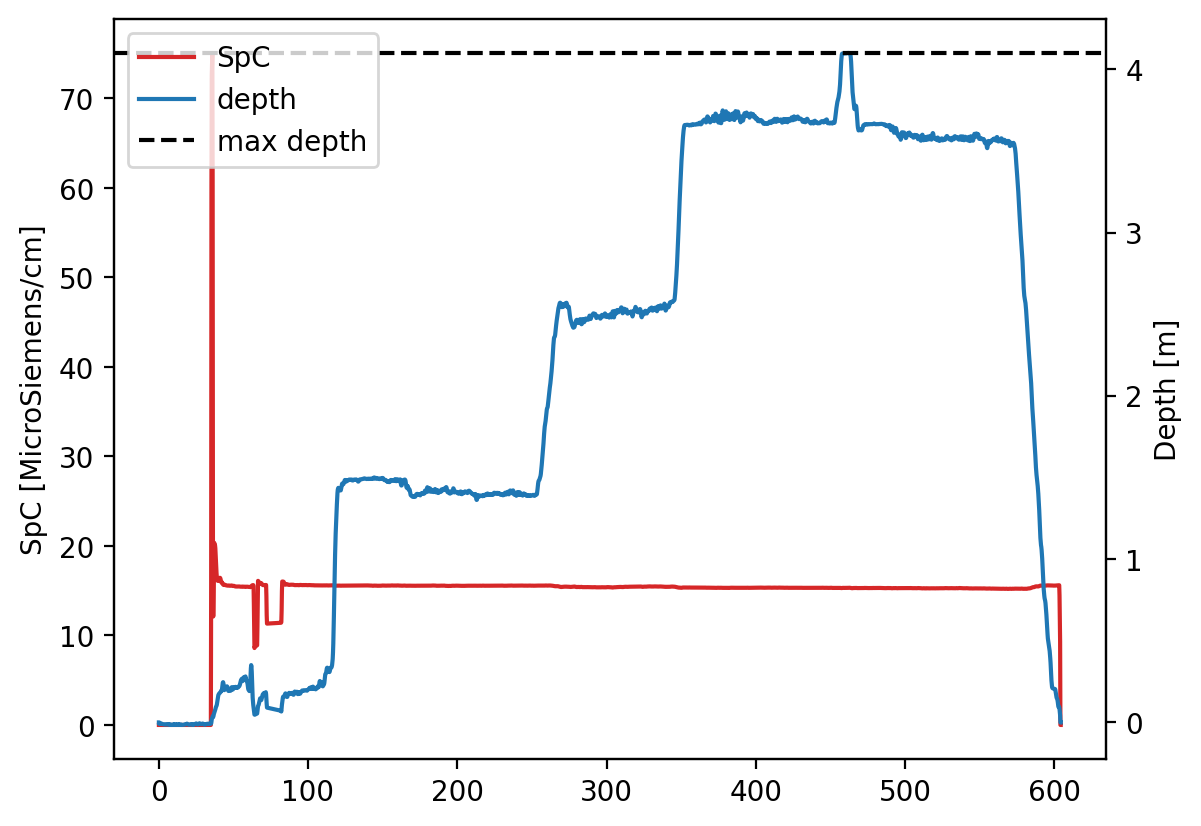

In [5]:
# make a copy of the profile csv so that it is easily read in when creating the super data

if pd.read_csv(files[m],  nrows=1).shape[1] == 2:
    ctd_profile = pd.read_csv(files[m], skiprows = 28)
    ctd_profile.to_csv('CTD-profile.csv',index = False)
else:
    shutil.copyfile(files[m], 'CTD-profile.csv')

# get the ctd file, rearrange it and make it into a dataframe 

ctd_data = pd.read_csv(files[n], skiprows = 28)
ctd_header = pd.read_csv(files[n], nrows = 27)
ctd = pd.concat([ctd_data, ctd_header], axis=1)

# associated a full corrected day and time stamp with each time series measurement

# select the start time
if tc_ctd_time_used == 1:
    cor_time = ctd.iloc[1,5] # UTC time
else:
    cor_time = ctd.iloc[2,5] # Local time
    
cor_time = datetime.strptime(cor_time,'%Y-%m-%d %H:%M:%S')
cor_time = cor_time + timedelta(hours=hrC,minutes=minC,seconds=scC)    ##Change time to CST

N = len(ctd.iloc[:,0])
cor_timess = np.empty(N, dtype=object)
for i in np.arange(0,N):
    cor_times = cor_time + timedelta(seconds = ctd.iloc[i,0])
    cor_timess[i] = cor_times.strftime("%m%d%Y%H%M%S") 
    
# average P,T,C from CTD data, calculate specific conductance from C and convert P to depth

avg_ctd_P = np.zeros(N)
avg_ctd_T = np.zeros(N)
avg_ctd_C = np.zeros(N)
for i in np.arange(2,N-2):
    avg_ctd_P[i] = np.average([ctd.iloc[i-2,1],ctd.iloc[i-1,1],ctd.iloc[i,1],ctd.iloc[i+1,1],ctd.iloc[i+2,1]])
    avg_ctd_T[i] = np.average([ctd.iloc[i-2,2],ctd.iloc[i-1,2],ctd.iloc[i,2],ctd.iloc[i+1,2],ctd.iloc[i+2,2]])
    avg_ctd_C[i] = np.average([ctd.iloc[i-2,3],ctd.iloc[i-1,3],ctd.iloc[i,3],ctd.iloc[i+1,3],ctd.iloc[i+2,3]])
    
avg_SpC = SpC(avg_ctd_C,avg_ctd_T)      #microsiemens/cm
depth = avg_ctd_P*10/9.81               #meters 

# insert data into ctd dataframe and save as a csv file

ctd.insert(0,'Time',cor_timess)
ctd.insert(1,'Depth [m]',depth)
ctd.insert(2,'P [Decibars]',avg_ctd_P)
ctd.insert(3,'T [Celsius]',avg_ctd_T)
ctd.insert(4,'SpC [MicroSiemens/cm]',avg_ctd_C)

ctd.to_csv('CTD-timeseries.csv',index = False)

display(ctd)

# auto set the max detph
maxdepth = max(ctd['Depth [m]'])

# plot the data
fig, ax1 = plt.subplots()
ax1.plot(ctd['Time (Seconds)'], ctd['SpC [MicroSiemens/cm]'], color='C03',alpha=1,label='SpC')
ax1.set_ylabel('SpC [MicroSiemens/cm]')
# ax1.set_ylim(33000,37000)
ax2 = ax1.twinx()
ax2.plot(ctd['Time (Seconds)'], ctd['Depth [m]'], alpha=1,label='depth')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Depth [m]')
ax2.axhline(y = maxdepth, color = 'k', linestyle = '--', label='max depth')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, loc=2);

## Auto Identify the break points for specific subsets of the data and the max depth

### find the initial breaks

Found 6 constant depth periods:

breakpoint_1: 0.2s - 61.6s (duration: 61.4s, avg depth: 0.14m)
breakpoint_2: 82.0s - 116.8s (duration: 34.8s, avg depth: 0.25m)
breakpoint_3: 120.4s - 257.4s (duration: 137.0s, avg depth: 1.55m)
breakpoint_4: 265.0s - 346.4s (duration: 81.4s, avg depth: 2.52m)
breakpoint_5: 351.8s - 456.6s (duration: 104.8s, avg depth: 3.79m)
breakpoint_6: 468.6s - 574.4s (duration: 105.8s, avg depth: 3.53m)

If you want to detect more breakpoints, try:
  - reducing 'depth_threshold' (e.g., 0.05 or 0.08)
  - reducing 'min_duration' (e.g., 5 seconds)
If you want to detect fewer, increase these values.


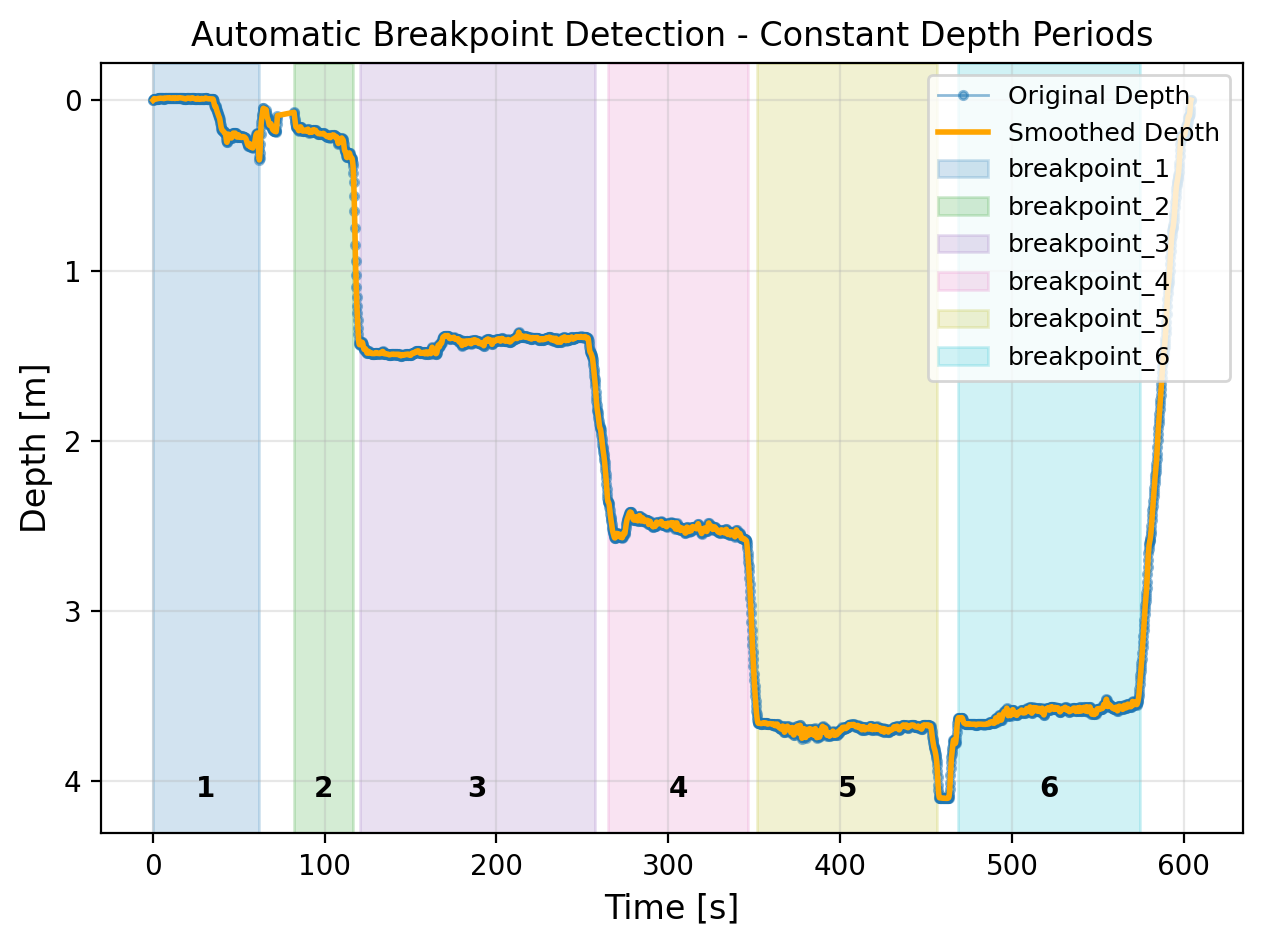

The shaded regions show detected constant depth periods.
The smoothed line (orange) is used for the slope analysis.


In [8]:
# Run the breakpoint detection
# You can adjust these parameters:
#   - depth_threshold: lower = more sensitive (smaller depth changes detected as "flat")
#   - min_duration: lower = more breakpoints (allows shorter flat periods)
#   - window_size: larger = more robust to noise
#   - smooth_window: larger = more smoothing (must be odd number)
#   - poly_order: higher = better feature preservation

breakpoints, suggested_names, depth_smooth = detect_constant_depth_periods(ctd, depth_threshold=0.1, min_duration=20, window_size=5, smooth_window=5, poly_order=3)

print(f"Found {len(breakpoints)} constant depth periods:\n")
for i, (start, end) in enumerate(breakpoints):
    duration = end - start
    start_idx = np.argmin(np.abs(ctd['Time (Seconds)'] - start))
    end_idx = np.argmin(np.abs(ctd['Time (Seconds)'] - end))
    start_depth = ctd['Depth [m]'].iloc[start_idx]
    end_depth = ctd['Depth [m]'].iloc[end_idx]
    avg_depth = (start_depth + end_depth) / 2
    print(f"{suggested_names[i]}: {start:.1f}s - {end:.1f}s (duration: {duration:.1f}s, avg depth: {avg_depth:.2f}m)")

print("\nIf you want to detect more breakpoints, try:")
print("  - reducing 'depth_threshold' (e.g., 0.05 or 0.08)")
print("  - reducing 'min_duration' (e.g., 5 seconds)")
print("If you want to detect fewer, increase these values.")

# Visualize the results: original depth, smoothed depth, and detected breakpoints
fig, ax = plt.subplots()

# Plot original depth data
ax.plot(ctd['Time (Seconds)'], ctd['Depth [m]'], 'o-', label='Original Depth', alpha=0.5, linewidth=1, markersize=3)

# Plot smoothed depth data
ax.plot(ctd['Time (Seconds)'], depth_smooth, '-', label='Smoothed Depth', linewidth=2, color='orange')

# Highlight the detected breakpoints with vertical shaded regions
colors = plt.cm.tab10(np.linspace(0, 1, len(breakpoints)))
for i, (start, end) in enumerate(breakpoints):
    ax.axvspan(start, end, alpha=0.2, color=colors[i], label=f'{suggested_names[i]}')
    # Mark the center of each breakpoint
    center = (start + end) / 2
    ax.text(center, ax.get_ylim()[1] * 0.95, f'{i+1}', ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Time [s]', fontsize=12)
ax.set_ylabel('Depth [m]', fontsize=12)
ax.set_title('Automatic Breakpoint Detection - Constant Depth Periods')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Invert y-axis so depth increases downward

plt.tight_layout()
plt.show()

print("The shaded regions show detected constant depth periods.")
print("The smoothed line (orange) is used for the slope analysis.")

### Merge any identified regions

Note that you must use the index values (1 less than the ones in the figure above)

After merging: 5 breakpoint groups

breakpoint_1: 0.2s - 61.6s (duration: 61.4s, avg depth: 0.14m)
breakpoint_2: 82.0s - 116.8s (duration: 34.8s, avg depth: 0.25m)
breakpoint_3: 120.4s - 257.4s (duration: 137.0s, avg depth: 1.55m)
breakpoint_4: 265.0s - 346.4s (duration: 81.4s, avg depth: 2.52m)
breakpoint_5_to_6: 351.8s - 574.4s (duration: 222.6s, avg depth: 3.53m)


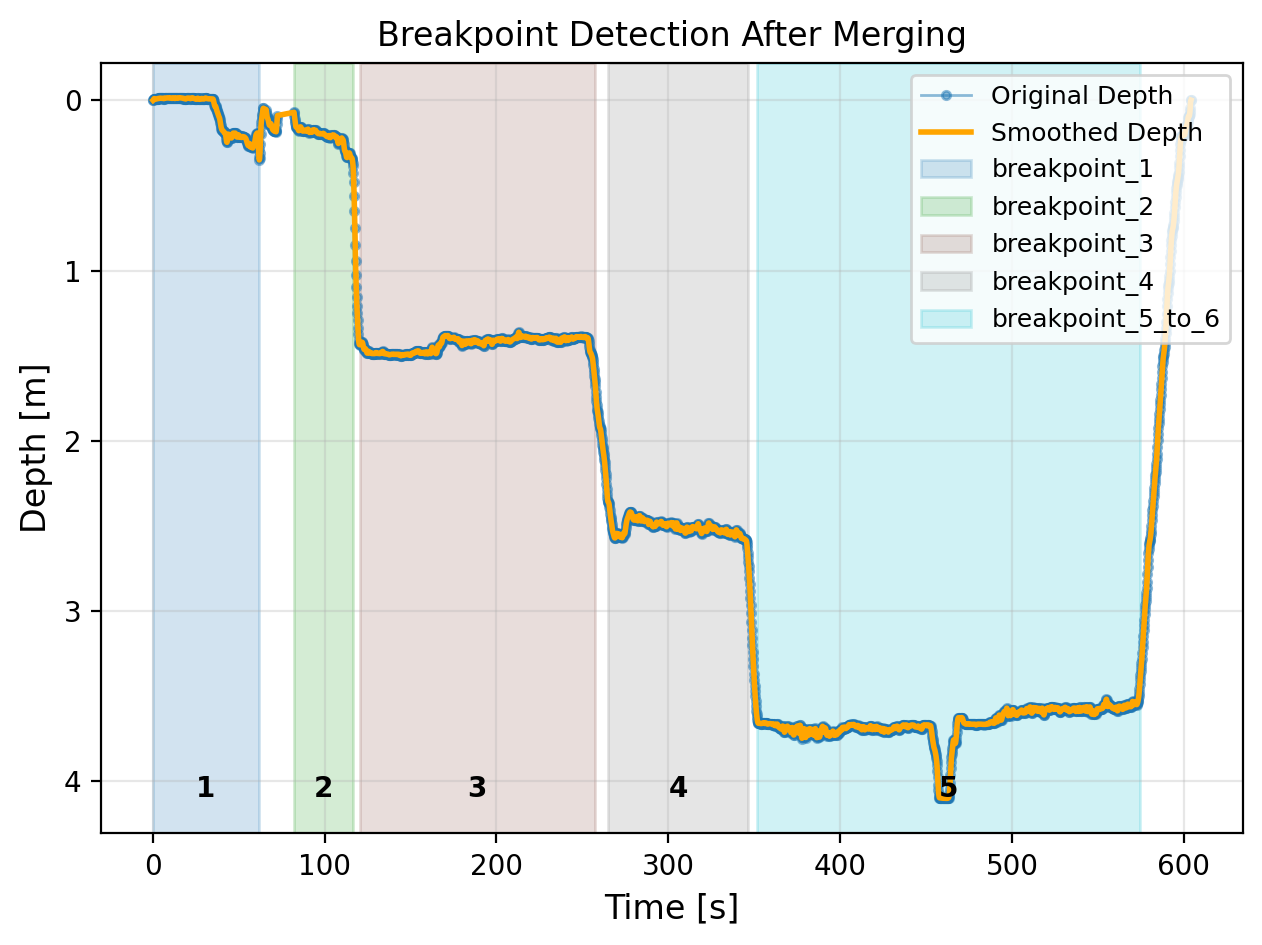

In [9]:
## Optional: Combine adjacent breakpoints if needed

# If you want to merge certain breakpoints together, specify them here.
# For example, if you want to combine breakpoint_1 and breakpoint_2, set:
# merge_groups = [[0, 1], [4, 5, 6]]  (uses 0-based indexing)
# Leave empty [] if you don't want to merge anything.
merge_groups = [[4,5]]  # Example: [[0, 1], [3, 4]] would merge groups 0+1 and 3+4

if merge_groups:
    # Create a mapping of which group each breakpoint belongs to
    group_mapping = {}
    for group_idx, indices in enumerate(merge_groups):
        for bp_idx in indices:
            group_mapping[bp_idx] = group_idx
    
    # Rebuild breakpoints and names after merging
    merged_breakpoints = []
    merged_names = []
    
    for group_idx in sorted(set(group_mapping.values())):
        indices = [i for i, g in group_mapping.items() if g == group_idx]
        indices.sort()
        
        # Get the start time of the first breakpoint and end time of the last breakpoint
        start_time = breakpoints[indices[0]][0]
        end_time = breakpoints[indices[-1]][1]
        merged_breakpoints.append((start_time, end_time))
        
        # Create a name combining the merged indices
        merged_name = f"breakpoint_{indices[0]+1}_to_{indices[-1]+1}"
        merged_names.append(merged_name)
    
    # Add any unmerged breakpoints
    for i in range(len(breakpoints)):
        if i not in group_mapping:
            merged_breakpoints.append(breakpoints[i])
            merged_names.append(suggested_names[i])
    
    # Sort by start time to maintain order
    sorted_pairs = sorted(zip(merged_breakpoints, merged_names))
    breakpoints = [bp for bp, name in sorted_pairs]
    suggested_names = [name for bp, name in sorted_pairs]
    
    print(f"After merging: {len(breakpoints)} breakpoint groups\n")
    for i, (start, end) in enumerate(breakpoints):
        duration = end - start
        start_idx = np.argmin(np.abs(ctd['Time (Seconds)'] - start))
        end_idx = np.argmin(np.abs(ctd['Time (Seconds)'] - end))
        start_depth = ctd['Depth [m]'].iloc[start_idx]
        end_depth = ctd['Depth [m]'].iloc[end_idx]
        avg_depth = (start_depth + end_depth) / 2
        print(f"{suggested_names[i]}: {start:.1f}s - {end:.1f}s (duration: {duration:.1f}s, avg depth: {avg_depth:.2f}m)")
else:
    print("No merging applied. Using original breakpoints.")

# Re-visualize after merging to see the updated breakpoints
fig, ax = plt.subplots()
ax.plot(ctd['Time (Seconds)'], ctd['Depth [m]'], 'o-', label='Original Depth', alpha=0.5, linewidth=1, markersize=3)
ax.plot(ctd['Time (Seconds)'], depth_smooth, '-', label='Smoothed Depth', linewidth=2, color='orange')

# Highlight the (possibly merged) breakpoints with vertical shaded regions
colors = plt.cm.tab10(np.linspace(0, 1, len(breakpoints)))
for i, (start, end) in enumerate(breakpoints):
    ax.axvspan(start, end, alpha=0.2, color=colors[i], label=f'{suggested_names[i]}')
    # Mark the center of each breakpoint
    center = (start + end) / 2
    ax.text(center, ax.get_ylim()[1] * 0.95, f'{i+1}', ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Time [s]', fontsize=12)
ax.set_ylabel('Depth [m]', fontsize=12)
ax.set_title('Breakpoint Detection After Merging')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Invert y-axis so depth increases downward

plt.tight_layout()
plt.show()

### Remove any unwanted breaks

Again, you must use the index value, 1 less than what is shown in the figure above

No breakpoints removed. Keeping all breakpoints.


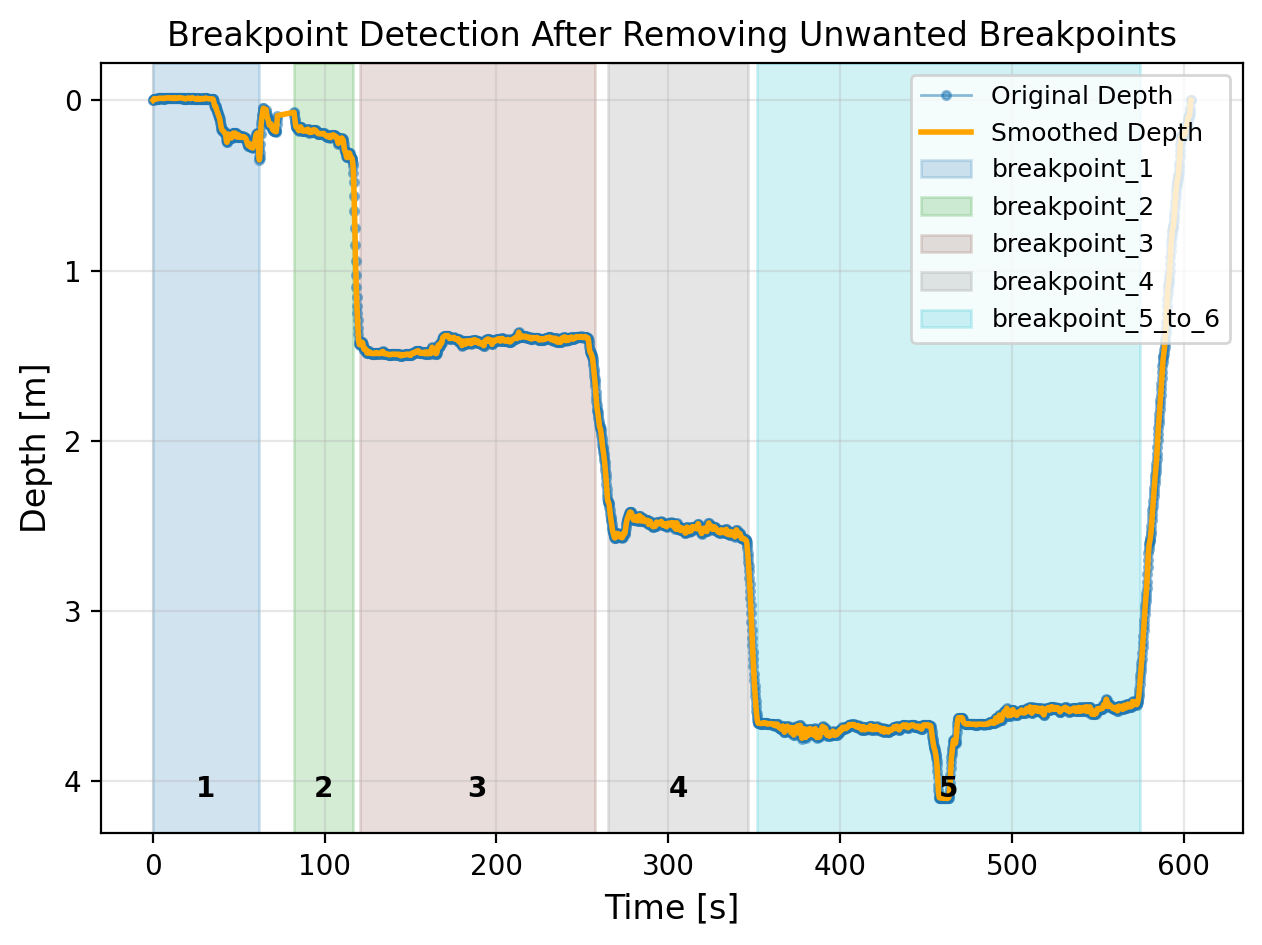

In [10]:
## Optional: Remove unwanted breakpoints

# Specify the indices of any breakpoints you want to remove (0-based indexing)
# For example: exclude_indices = [2, 4] would remove breakpoint 3 and 5
exclude_indices = []  # Leave empty [] if you want to keep all breakpoints

if exclude_indices:
    # Sort indices in reverse order to avoid index shifting issues
    for idx in sorted(exclude_indices, reverse=True):
        if 0 <= idx < len(breakpoints):
            breakpoints.pop(idx)
            suggested_names.pop(idx)
    
    print(f"After removing {len(exclude_indices)} breakpoint(s): {len(breakpoints)} breakpoint groups remain\n")
    for i, (start, end) in enumerate(breakpoints):
        duration = end - start
        start_idx = np.argmin(np.abs(ctd['Time (Seconds)'] - start))
        end_idx = np.argmin(np.abs(ctd['Time (Seconds)'] - end))
        start_depth = ctd['Depth [m]'].iloc[start_idx]
        end_depth = ctd['Depth [m]'].iloc[end_idx]
        avg_depth = (start_depth + end_depth) / 2
        print(f"{suggested_names[i]}: {start:.1f}s - {end:.1f}s (duration: {duration:.1f}s, avg depth: {avg_depth:.2f}m)")
else:
    print("No breakpoints removed. Keeping all breakpoints.")

# Re-visualize after removal
fig, ax = plt.subplots()
ax.plot(ctd['Time (Seconds)'], ctd['Depth [m]'], 'o-', label='Original Depth', alpha=0.5, linewidth=1, markersize=3)
ax.plot(ctd['Time (Seconds)'], depth_smooth, '-', label='Smoothed Depth', linewidth=2, color='orange')

colors = plt.cm.tab10(np.linspace(0, 1, len(breakpoints)))
for i, (start, end) in enumerate(breakpoints):
    ax.axvspan(start, end, alpha=0.2, color=colors[i], label=f'{suggested_names[i]}')
    # Mark the center of each breakpoint
    center = (start + end) / 2
    ax.text(center, ax.get_ylim()[1] * 0.95, f'{i+1}', ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Time [s]', fontsize=12)
ax.set_ylabel('Depth [m]', fontsize=12)
ax.set_title('Breakpoint Detection After Removing Unwanted Breakpoints')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Invert y-axis so depth increases downward

plt.tight_layout()
plt.show()

### Now save the breakpoint or choose to enter them manually

In [11]:
""" --- User input ----------------------------- """
subsets = 1 # enter "1" to have subsets, zero for none
automax = 1 # use "1" to just take the max of the measurement. Set automax = 0 to use a user-specified value (then must set manual max below)
autobreaks = 1 # 1 is use the auto breaks... 0 is manual

names = np.array(['surface','d1','d2','d3','d4','d5','bottom']) # the number here must match the number of breaks

"""  ------------------------------------------- """

startS_auto = np.array([bp[0] for bp in breakpoints])
endS_auto = np.array([bp[1] for bp in breakpoints])

Manual settings (Skip if not using. Should be commented out)

In [138]:
if autobreaks == 0: 
    # plot the data
    fig, ax1 = plt.subplots()
    ax1.plot(ctd['Time (Seconds)'], ctd['SpC [MicroSiemens/cm]'], color='C03',alpha=1,label='SpC')
    ax1.set_ylabel('SpC [MicroSiemens/cm]')
    # ax1.set_ylim(33000,37000)
    ax2 = ax1.twinx()
    ax2.plot(ctd['Time (Seconds)'], ctd['Depth [m]'], alpha=1,label='depth')
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('Depth [m]')
    ax2.axhline(y = maxdepth, color = 'k', linestyle = '--', label='max depth')
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1+h2, l1+l2, loc=2);



In [139]:
""" --- User input ----------------------------- """
# manualmax = 12.8 # Set max depth manually

# Xingu - --------------------------------

# names = np.array(['surface','d1','d2','bottom'])
# startS_man = np.array([141,258,347,482]) # Cast01 - xingu
# endS_man = np.array([242,325,467,714]) # Cast01 - xingu

# names = np.array(['surface','d1','d2','bottom'])
# startS = np.array([41,122,268,350]) # Cast01 - xingu
# endS = np.array([113,250,347,573]) # Cast01 - xingu

# names = np.array(['surface','d1','d2','bottom'])
# startS = np.array([65,180,275,385]) # Cast03 - xingu
# endS = np.array([167,267,378,464]) # Cast03 - xingu

# # Seine - 4/17/2022 --------------------------------

# names = np.array(['profile','surface','mid-depth','bottom'])

# startS = np.array([62,235,358,458]) # profile 4
# endS = np.array([234,322,415,528]) # profile 4

# # Seine - 6/16/2022 --------------------------------

# names = np.array(['profile','surface','mid-depth','bottom'])

# startS = np.array([180,338,553,714]) # profile 4
# endS = np.array([338,518,679,832]) # profile 4


"""  ------------------------------------------- """

'  ------------------------------------------- '

In [140]:
if autobreaks == 1:
    startS = startS_auto
    endS = endS_auto
else:
    startS = startS_man
    endS = endS_man

if automax == 0:
    maxdepth = manualmax
else:
    waterdepth = pd.DataFrame({'Depth [m]':np.array([maxdepth])})
    waterdepth.to_csv('Depth.csv',index=False)
    
if subsets == 1:
    
    deltaT = endS - startS
    start_time = np.zeros(len(startS))
    end_time = np.zeros(len(endS))

    for i in range(0,len(startS)):
        temp = ctd[(ctd['Time (Seconds)'] == startS[i])].copy()
        start_time[i] = temp.Time.iloc[0]

    for i in range(0,len(endS)):
        temp = ctd[(ctd['Time (Seconds)'] == endS[i])].copy()
        end_time[i] = temp.Time.iloc[0]

    breaktimes = pd.DataFrame({'Type/Location':names,'Start [DateTime]':start_time, 'End [DateTime]':end_time, 'Durration [sec]':deltaT})
    breaktimes.to_csv('Data-Breakpionts.csv',index = False)
    display(breaktimes)



,Type/Location,Start [DateTime],End [DateTime],Durration [sec]
0,surface,1.001203e+13,1.001203e+13,67.2
1,d1,1.001203e+13,1.001203e+13,66.6
2,d2,1.001203e+13,1.001203e+13,59.0
3,d3,1.001203e+13,1.001203e+13,49.2
4,d4,1.001203e+13,1.001203e+13,58.6
5,d5,1.001203e+13,1.001203e+13,59.2
6,bottom,1.001203e+13,1.001203e+13,57.6


## Save the depth to be used later on

In [141]:
pd.DataFrame({'Depth [m]':np.array([maxdepth])})

,Depth [m]
0,15.691099


## Extract time stamps from images and save as a csv file

In [142]:
# find the list of images, build a dataframe, and then extract the date time

# uses the filemod_list.csv file ---------------

images = pd.read_csv('filemod_list.csv', usecols = ['file_Name'])

N = len(images)
datetime_raw = np.empty(N, dtype=object)
for i in np.arange(0,N):
    datetime_raw[i] = str(images.iloc[i,0].split('-')[1]) #adjust the number in brackets until the datetime_raw is the timestamp. This will depend on how you named the images in the field. 
images['Image Time']=datetime_raw
images.to_csv('ImageTime.csv', index=False)
display(images)

# uses the actual image files -----------------
# Ifiles = sorted(glob.glob(imagetype))
# images=pd.DataFrame(Ifiles)

# N = len(images)
# datetime_raw = np.empty(N, dtype=object)
# for i in np.arange(0,N):
#     datetime_raw[i] = str(images.iloc[i,0].split('-')[1]) #adjust the number in brackets until the datetime_raw is the timestamp. This will depend on how you named the images in the field. 
# images['Image Time']=datetime_raw
# images.to_csv('ImageTime.csv', index=False)
# display(images)

# imagehold = images[(images['Image Time'] >= breaktime)].copy()
# imagehold.to_csv('ImageTime-hold.csv',index = False)
# print("Only during the hold ------------")
# display(imagehold)

,file_Name,Image Time
0,cast10-10012025153702-0.Bmp,10012025153702
1,cast10-10012025153702-1.Bmp,10012025153702
2,cast10-10012025153703-2.Bmp,10012025153703
3,cast10-10012025153703-3.Bmp,10012025153703
4,cast10-10012025153704-4.Bmp,10012025153704
...,...,...
1164,cast10-10012025154644-1164.Bmp,10012025154644
1165,cast10-10012025154644-1165.Bmp,10012025154644
1166,cast10-10012025154645-1166.Bmp,10012025154645
1167,cast10-10012025154645-1167.Bmp,10012025154645


In [143]:
# change the working directory back to the original code path
os.chdir(CodePath)